In [10]:
import os
import torch
import torch.nn.functional as F
from torch.optim import Adam
from tqdm.auto import tqdm, trange
import argparse
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from dataset_swat import ForecastSimpleDataloader
from code_test import test

import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from fddbenchmark import FDDDataset
from dataset3 import ForecastFDDDataloader
import numpy as np
from tqdm.auto import tqdm, trange

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from gsl import GSL
import math

class GCLayer(nn.Module):
    """
    Graph convolution layer.
    """
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.dense = nn.Linear(in_dim, out_dim)

    def forward(self, adj, X):
        adj = adj + torch.eye(adj.size(0)).to(adj.device)
        h = self.dense(X)
        norm = adj.sum(1)**(-1/2)
        h = norm[None, :] * adj * norm[:, None] @ h
        return h

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(MultiHeadSelfAttention, self).__init__()
        self.d_head = d_model // nhead
        self.nhead = nhead
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (B, T, d_model)
        B, T, d_model = x.size()
        Q = self.W_q(x)  # (B, T, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        # (B, T, nhead, d_head) -> (B, nhead, T, d_head)
        Q = Q.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        # (B, nhead, T, T)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)  # (B, nhead, T, d_head)
        # (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, d_model)
        out = self.out_proj(out)
        return out

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadSelfAttention(d_model, nhead, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = PositionwiseFeedForward(d_model, dim_feedforward, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        attn_out = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class TimeSeriesTransformerGSL(nn.Module):
    def __init__(self, ts_dim, window_size, d_model=64, nhead=4, num_layers=2, 
                 dim_feedforward=128, dropout=0.1, 
                 gsl_k=None, gsl_alpha=1.0, 
                 n_gnn=1, n_hidden=1024, device='cpu'):
        super().__init__()
        self.ts_dim = ts_dim
        self.window_size = window_size
        self.device = device
        
        self.input_proj = nn.Linear(ts_dim, d_model)
        
        pe = torch.zeros(1, window_size, d_model)
        position = torch.arange(0, window_size).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
        
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        self.n_gnn = n_gnn
        self.gsl = nn.ModuleList()
        self.conv1 = nn.ModuleList()
        self.bnorm1 = nn.ModuleList()
        self.conv2 = nn.ModuleList()
        self.bnorm2 = nn.ModuleList()
        self.z = (torch.ones(ts_dim, ts_dim) - torch.eye(ts_dim)).to(device)
        
        for _ in range(n_gnn):
            self.gsl.append(GSL(gsl_type='undirected', 
                                n_nodes=ts_dim, 
                                window_size=window_size, 
                                alpha=gsl_alpha, 
                                k=gsl_k, 
                                device=device))
            self.conv1.append(GCLayer(window_size, n_hidden))
            self.bnorm1.append(nn.BatchNorm1d(ts_dim))
            self.conv2.append(GCLayer(n_hidden, n_hidden))
            self.bnorm2.append(nn.BatchNorm1d(ts_dim))

        combined_dim = d_model + n_gnn * n_hidden
        self.fc = nn.Linear(combined_dim, combined_dim//2)
        self.fc_out = nn.Linear(combined_dim//2, ts_dim)

    def forward(self, x):
        B, T, N = x.size()
        
        x_proj = self.input_proj(x) + self.pe[:, :T, :]
        
        for layer in self.layers:
            x_proj = layer(x_proj)
        
        transformer_feat = x_proj.mean(dim=1)  # (B, d_model)
        transformer_feat = self.dropout(transformer_feat)

        x_gnn = x.transpose(1, 2)  # (B, N, T)
        gnn_features = []
        
        for i in range(self.n_gnn):
            adj = self.gsl[i](torch.arange(N).to(self.device)) * self.z
            h = self.conv1[i](adj, x_gnn).relu()
            h = self.bnorm1[i](h)
            skip, _ = torch.min(h, dim=1)
            h = self.conv2[i](adj, h).relu()
            h = self.bnorm2[i](h)
            h, _ = torch.min(h, dim=1)
            h += skip
            gnn_features.append(h)
        
        graph_feat = torch.cat(gnn_features, dim=1)  # (B, n_gnn*n_hidden)
        graph_feat = self.dropout(graph_feat)

        combined = torch.cat((transformer_feat, graph_feat), dim=-1)
        out = F.sigmoid(self.fc(combined))
        out = self.fc_out(out)
        return out

In [12]:
df_train = df_norm
df_norm['Normal/Attack'] = 0
df_train[feature_cols] = df_train[feature_cols].astype('float32')

In [13]:
ts_dim = len(feature_cols)

In [14]:
train_dl = ForecastSimpleDataloader(
        dataframe=df_train,
        window_size=100,
        step_size=1,
        use_minibatches=True,
        batch_size=512,
        shuffle=True,
        data_framework='torch',
        device='cpu',
        train=True,            
        timestamp_col='Timestamp',
        label_col='Normal/Attack',
        disable_index=False,
        random_state=42
)

In [15]:
model.eval()
embeds = []
with torch.no_grad():
    for i in range(len(train_dl) - 1):
        ts_batch, _, target_batch, _ = train_dl[i]
        embeds.extend(forwad_pass(model, ts_batch))

NameError: name 'forwad_pass' is not defined

In [37]:
all_errors_train = []
all_true_labels_train = []
all_errors_vec_train = []

for i in range(len(train_dl) - 1):
    ts_batch, _, target_batch, label = train_dl[i]
    pred = model(ts_batch)

    target_raw = scaler.inverse_transform(target_batch.cpu().detach().numpy())
    pred_raw = scaler.inverse_transform(pred.cpu().detach().numpy())

    errors = target_raw - pred_raw
    all_errors_vec_train.extend(errors)
    all_errors_train.extend(abs(errors).mean(axis=1))

In [ ]:
all_errors_vec_train = np.stack(all_errors_vec_train)

In [ ]:
a = np.concatenate([all_errors_vec_train, embeds], axis=1)

In [ ]:
a.shape

In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('WADI_14days.csv')

In [18]:
attack_wadi = pd.read_csv('/home/akozhevnikov/graphs/ts-gnn-tam/WADI_attackdata.csv')

In [19]:
df['Normal/Attack'] = 0
df = df.drop(['Row', 'Date'], axis=1)
df[df.columns[1:]] = df[df.columns[1:]].fillna(0)

In [20]:
feature_cols = [c for c in df.columns if c not in ['Time', 'Normal/Attack']]

In [21]:
scaler = StandardScaler()
scaler.fit(df[feature_cols])
df[feature_cols] = df[feature_cols].astype('float32')

In [22]:
df[feature_cols] = scaler.transform(df[feature_cols])

In [23]:
train_dl = ForecastSimpleDataloader(
        dataframe=df,
        window_size=100,
        step_size=1,
        use_minibatches=True,
        batch_size=512,
        shuffle=True,
        data_framework='torch',
        device='cpu',
        train=True,             
        timestamp_col='Time',
        label_col='Normal/Attack',
        disable_index=False,
        random_state=42
)

In [24]:
attack_wadi['timestamp'] = pd.to_datetime(
    attack_wadi['Date'].str.strip() + ' ' + attack_wadi['Time'].str.strip(),
    format='%m/%d/%Y %I:%M:%S.%f %p'
)

In [25]:
attack_dates = [
    ['9/10/17 19:25:00', '9/10/17 19:50:16'],
    ['10/10/17 10:24:10', '10/10/17 10:34:00'],
    ['10/10/17 10:55:00', '10/10/17 11:24:00'],
    ['10/10/17 11:30:40', '10/10/17 11:44:50'],
    ['10/10/17 13:39:30', '10/10/17 13:50:40'],
    ['10/10/17 14:48:17', '10/10/17 14:59:55'], 
    ['10/10/17 17:40:00', '10/10/17 17:49:40'],
    ['11/10/17 10:55:00', '11/10/17 10:56:27'],
    ['11/10/17 11:17:54', '11/10/17 11:31:20'],
    ['11/10/17 11:36:31', '11/10/17 11:47:00'],
    ['11/10/17 11:59:00', '11/10/17 12:05:00'],
    ['11/10/17 12:07:30', '11/10/17 12:10:52'],
    ['11/10/17 12:16:00', '11/10/17 12:25:36'],
    ['11/10/17 15:26:30', '11/10/17 15:37:00'],
]

attacks_df = pd.DataFrame(attack_dates, columns=['start', 'end'])
attacks_df['start_dt'] = pd.to_datetime(attacks_df['start'], format='%m/%d/%y %H:%M:%S')
attacks_df['end_dt']   = pd.to_datetime(attacks_df['end'],   format='%m/%d/%y %H:%M:%S')

In [26]:
attack_wadi['label'] = 0
for _, attack in attacks_df.iterrows():
    mask = attack_wadi['timestamp'].between(attack['start_dt'], attack['end_dt'])
    attack_wadi.loc[mask, 'label'] = 1

In [27]:
attack_wadi['label'].value_counts()

label
0    167667
1      5134
Name: count, dtype: int64

In [28]:
attack_wadi = attack_wadi.drop(['Row', 'Date', 'timestamp'], axis=1)
attack_wadi[attack_wadi.columns[1:]] = attack_wadi[attack_wadi.columns[1:]].fillna(0).astype('float32')

In [29]:
attack_wadi[feature_cols] = scaler.transform(attack_wadi[feature_cols]).astype('float32')

In [30]:
test_dl = ForecastSimpleDataloader(
    dataframe=attack_wadi,
    window_size=100,
    step_size=1,
    use_minibatches=True,
    batch_size=512,
    shuffle=False,
    data_framework='torch',
    device='cpu',
    train=False, 
    timestamp_col='Time',
    label_col='label',
    disable_index=False
)

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from gsl import GSL
import math 

class GCLayer(nn.Module):

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.dense = nn.Linear(in_dim, out_dim)

    def forward(self, adj, X):
        adj = adj + torch.eye(adj.size(0)).to(adj.device)
        h = self.dense(X)
        norm = adj.sum(1)**(-1/2)
        h = norm[None, :] * adj * norm[:, None] @ h
        return h

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1):
        super(MultiHeadSelfAttention, self).__init__()
        self.d_head = d_model // nhead
        self.nhead = nhead
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x: (B, T, d_model)
        B, T, d_model = x.size()
        Q = self.W_q(x)  # (B, T, d_model)
        K = self.W_k(x)
        V = self.W_v(x)
        # (B, T, nhead, d_head) -> (B, nhead, T, d_head)
        Q = Q.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        K = K.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        V = V.view(B, T, self.nhead, self.d_head).transpose(1, 2)
        # (B, nhead, T, T)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, V)  # (B, nhead, T, d_head)
        # (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, d_model)
        out = self.out_proj(out)
        return out

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.attn = MultiHeadSelfAttention(d_model, nhead, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = PositionwiseFeedForward(d_model, dim_feedforward, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class TimeSeriesTransformerGSL(nn.Module):
    def __init__(self, ts_dim, window_size, d_model=64, nhead=4, num_layers=2, 
                 dim_feedforward=128, dropout=0.1, 
                 gsl_k=None, gsl_alpha=1.0, 
                 n_gnn=1, n_hidden=1024, device='cpu'):
        super().__init__()
        self.ts_dim = ts_dim
        self.window_size = window_size
        self.device = device
        
        self.input_proj = nn.Linear(ts_dim, d_model)
        
        pe = torch.zeros(1, window_size, d_model)
        position = torch.arange(0, window_size).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)
        
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        self.n_gnn = n_gnn
        self.gsl = nn.ModuleList()
        self.conv1 = nn.ModuleList()
        self.bnorm1 = nn.ModuleList()
        self.conv2 = nn.ModuleList()
        self.bnorm2 = nn.ModuleList()
        self.z = (torch.ones(ts_dim, ts_dim) - torch.eye(ts_dim)).to(device)
        
        for _ in range(n_gnn):
            self.gsl.append(GSL(gsl_type='undirected', 
                                n_nodes=ts_dim, 
                                window_size=window_size, 
                                alpha=gsl_alpha, 
                                k=gsl_k, 
                                device=device))
            self.conv1.append(GCLayer(window_size, n_hidden))
            self.bnorm1.append(nn.BatchNorm1d(ts_dim))
            self.conv2.append(GCLayer(n_hidden, n_hidden))
            self.bnorm2.append(nn.BatchNorm1d(ts_dim))

        combined_dim = d_model + n_gnn * n_hidden
        self.fc = nn.Linear(combined_dim, combined_dim//2)
        self.fc_out = nn.Linear(combined_dim//2, ts_dim)

    def forward(self, x):
        B, T, N = x.size()
        
        x_proj = self.input_proj(x) + self.pe[:, :T, :]
        
        for layer in self.layers:
            x_proj = layer(x_proj)
        
        transformer_feat = x_proj.mean(dim=1)  # (B, d_model)
        transformer_feat = self.dropout(transformer_feat)

        x_gnn = x.transpose(1, 2)  # (B, N, T)
        gnn_features = []
        
        for i in range(self.n_gnn):
            adj = self.gsl[i](torch.arange(N).to(self.device)) * self.z
            h = self.conv1[i](adj, x_gnn).relu()
            h = self.bnorm1[i](h)
            skip, _ = torch.min(h, dim=1)
            h = self.conv2[i](adj, h).relu()
            h = self.bnorm2[i](h)
            h, _ = torch.min(h, dim=1)
            h += skip
            gnn_features.append(h)
        
        graph_feat = torch.cat(gnn_features, dim=1)  # (B, n_gnn*n_hidden)
        graph_feat = self.dropout(graph_feat)

        combined = torch.cat((transformer_feat, graph_feat), dim=-1)
        out = F.sigmoid(self.fc(combined))
        out = self.fc_out(out)
        return out

In [32]:
ts_dim = len(feature_cols)

In [33]:
model = TimeSeriesTransformerGSL(
        ts_dim=ts_dim,
        window_size=100,
        d_model=256,
        nhead=8,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2,
        gsl_k=1,
        n_gnn=1,
        n_hidden=256,
        device='cpu'
).to('cpu')

In [34]:
m = torch.load('/home/akozhevnikov/graphs/wadi/saved_models/swat_transformer_gsl_wadi_baseline.pt', weights_only=True)
model.load_state_dict(m, strict=False)

_IncompatibleKeys(missing_keys=['pe'], unexpected_keys=[])

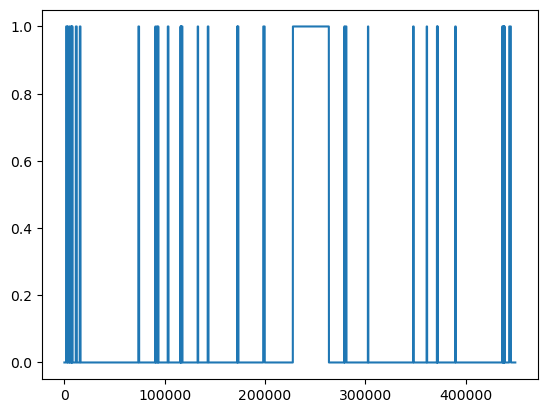

In [35]:
plt.plot(all_true_labels)

In [36]:
all_errors = []
all_true_labels = []
all_errors_vec = []

for i in range(len(test_dl) - 1):
    ts_batch, _, target_batch, label = test_dl[i]
    pred = model(ts_batch)

    target_raw = scaler.inverse_transform(target_batch.cpu().detach().numpy())
    pred_raw = scaler.inverse_transform(pred.cpu().detach().numpy())

    errors = target_raw - pred_raw
    all_errors_vec.extend(errors)
    all_errors.extend(abs(errors).mean(axis=1))
    all_true_labels.extend(label)

In [161]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, f1_score

all_errors = np.stack(all_errors_vec)
all_true_labels = np.array(all_true_labels)

X_train, X_test, y_train, y_test = train_test_split(
    all_errors, all_true_labels,
    test_size=1-(0.00667*2),
    shuffle=True,
    random_state=42,
)

In [153]:
from catboost import CatBoostClassifier

c = CatBoostClassifier(iterations=10000, early_stopping_rounds=5, class_weights=(0.7, 0.3))
c.fit(X_train, y_train)
pred = c.predict(X_test)

Learning rate set to 0.002117
0:	learn: 0.6883531	total: 2.95ms	remaining: 29.5s
1:	learn: 0.6837701	total: 6.1ms	remaining: 30.5s
2:	learn: 0.6792453	total: 8.27ms	remaining: 27.6s
3:	learn: 0.6747178	total: 10.5ms	remaining: 26.2s
4:	learn: 0.6701752	total: 12.7ms	remaining: 25.3s
5:	learn: 0.6655828	total: 14.8ms	remaining: 24.7s
6:	learn: 0.6608909	total: 16.9ms	remaining: 24.1s
7:	learn: 0.6564127	total: 19.1ms	remaining: 23.8s
8:	learn: 0.6520350	total: 21.3ms	remaining: 23.6s
9:	learn: 0.6474377	total: 24ms	remaining: 24s
10:	learn: 0.6431476	total: 26.5ms	remaining: 24.1s
11:	learn: 0.6388732	total: 28.8ms	remaining: 24s
12:	learn: 0.6345930	total: 31.2ms	remaining: 24s
13:	learn: 0.6300426	total: 33.6ms	remaining: 23.9s
14:	learn: 0.6260206	total: 35.9ms	remaining: 23.9s
15:	learn: 0.6217786	total: 38.2ms	remaining: 23.9s
16:	learn: 0.6176813	total: 40.6ms	remaining: 23.8s
17:	learn: 0.6134922	total: 43ms	remaining: 23.9s
18:	learn: 0.6092769	total: 45.4ms	remaining: 23.8s
19:

In [154]:
print(classification_report(y_test, pred))
print(len(X_train))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    164046
           1       0.97      0.62      0.76      5046

    accuracy                           0.99    169092
   macro avg       0.98      0.81      0.88    169092
weighted avg       0.99      0.99      0.99    169092

3452


In [146]:
print(type(all_errors)), print(all_errors.shape)

<class 'numpy.ndarray'>
(172544, 127)


(None, None)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report, f1_score

all_errors = np.stack(all_errors_vec)
all_true_labels = np.array(all_true_labels)

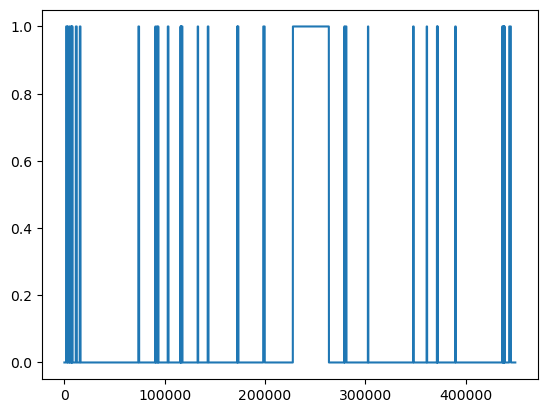

In [45]:
plt.plot(all_true_labels)

In [152]:
X_train = all_errors[:200_000]
y_train = all_true_labels[:200_000]

X_test_final = all_errors[200_000:]
y_test_final = all_true_labels[200_000:]

In [153]:
y_test_final.sum(), len(y_test_final)

(42864, 249536)

In [154]:
y_train.sum(), all_true_labels.sum()

(11757, 54621)

In [164]:
X_train_small, X_test, y_train_small, y_test = train_test_split(
    X_train, y_train,
    test_size=1-(0.00667*3),
    shuffle=True,
    random_state=42,
)

In [167]:
def augment_with_noise(X, noise_level=0.05, n_copies=1, random_state=None):
    rng = np.random.default_rng(random_state)
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    ranges = X_max - X_min

    augmented = []
    for _ in range(n_copies):
        noise = rng.uniform(
            low=-noise_level * ranges,
            high=+noise_level * ranges,
            size=X.shape
        )
        augmented.append(X + noise)
    return np.vstack(augmented)

def augment_with_masking(X, mask_prob=0.1, n_copies=1, random_state=None):
    rng = np.random.default_rng(random_state)
    augmented = []
    for _ in range(n_copies):
        mask = rng.random(size=X.shape) < mask_prob
        X_masked = X.copy()
        X_masked[mask] = 0.0
        augmented.append(X_masked)
    return np.vstack(augmented)

In [179]:
noise_copies = 2
mask_copies = 2

X_noise = augment_with_noise(X_train_small, noise_level=0.05, n_copies=noise_copies, random_state=42)
X_mask  = augment_with_masking(X_train_small, mask_prob=0.1, n_copies=mask_copies, random_state=42)

X_train_aug = np.vstack([X_train_small, X_noise, X_mask])
y_train_aug = np.concatenate([
    y_train_small,
    np.tile(y_train_small, noise_copies),
    np.tile(y_train_small, mask_copies),
])

In [180]:
from catboost import CatBoostClassifier

c = CatBoostClassifier(iterations=10000, early_stopping_rounds=5, class_weights=(0.5, 0.5))
c.fit(X_train_aug, y_train_aug)

Learning rate set to 0.004483
0:	learn: 0.6865248	total: 3.06ms	remaining: 30.7s
1:	learn: 0.6799439	total: 5.45ms	remaining: 27.2s
2:	learn: 0.6734546	total: 7.66ms	remaining: 25.5s
3:	learn: 0.6663138	total: 9.89ms	remaining: 24.7s
4:	learn: 0.6597463	total: 12.2ms	remaining: 24.3s
5:	learn: 0.6533283	total: 14.4ms	remaining: 24s
6:	learn: 0.6469555	total: 16.6ms	remaining: 23.7s
7:	learn: 0.6408542	total: 18.8ms	remaining: 23.5s
8:	learn: 0.6347333	total: 21ms	remaining: 23.3s
9:	learn: 0.6281713	total: 23.2ms	remaining: 23.2s
10:	learn: 0.6217027	total: 25.4ms	remaining: 23.1s
11:	learn: 0.6157162	total: 27.6ms	remaining: 23s
12:	learn: 0.6092978	total: 29.8ms	remaining: 22.9s
13:	learn: 0.6034172	total: 32.1ms	remaining: 22.9s
14:	learn: 0.5976839	total: 34.3ms	remaining: 22.8s
15:	learn: 0.5919013	total: 36.5ms	remaining: 22.8s
16:	learn: 0.5864248	total: 38.6ms	remaining: 22.7s
17:	learn: 0.5807748	total: 40.8ms	remaining: 22.6s
18:	learn: 0.5753937	total: 43ms	remaining: 22.6s


In [ ]:
noise_copies = 2
mask_copies = 2

X_noise = augment_with_noise(X_train, noise_level=0.05, n_copies=noise_copies, random_state=42)
X_mask  = augment_with_masking(X_train, mask_prob=0.1, n_copies=mask_copies, random_state=42)

X_train_aug = np.vstack([X_train, X_noise, X_mask])
y_train_aug = np.concatenate([
    y_train,
    np.tile(y_train, noise_copies),
    np.tile(y_train, mask_copies),
])

In [164]:
c = CatBoostClassifier(iterations=10000, early_stopping_rounds=5, class_weights=(0.5, 0.5))
c.fit(X_train_aug, y_train_aug)
pred = c.predict(X_test)

print(classification_report(y_test, pred))
f1 = f1_score(y_test, pred)
print(f"F1-score: {f1:.4f}")

Learning rate set to 0.003539
0:	learn: 0.6862487	total: 4.05ms	remaining: 40.5s
1:	learn: 0.6793706	total: 7.68ms	remaining: 38.4s
2:	learn: 0.6722552	total: 11.1ms	remaining: 37.1s
3:	learn: 0.6658821	total: 14.6ms	remaining: 36.5s
4:	learn: 0.6594797	total: 18ms	remaining: 36s
5:	learn: 0.6529524	total: 21.4ms	remaining: 35.7s
6:	learn: 0.6465551	total: 24.8ms	remaining: 35.4s
7:	learn: 0.6403588	total: 28.3ms	remaining: 35.4s
8:	learn: 0.6337362	total: 31.8ms	remaining: 35.3s
9:	learn: 0.6276343	total: 35.2ms	remaining: 35.2s
10:	learn: 0.6214952	total: 38.6ms	remaining: 35.1s
11:	learn: 0.6150611	total: 42.1ms	remaining: 35.1s
12:	learn: 0.6089903	total: 45.5ms	remaining: 35s
13:	learn: 0.6026581	total: 48.9ms	remaining: 34.9s
14:	learn: 0.5965402	total: 52.3ms	remaining: 34.8s
15:	learn: 0.5909374	total: 55.8ms	remaining: 34.8s
16:	learn: 0.5846057	total: 59.3ms	remaining: 34.8s
17:	learn: 0.5784245	total: 62.8ms	remaining: 34.8s
18:	learn: 0.5722413	total: 66.2ms	remaining: 34.8

In [170]:
pred = c.predict(X_test_final)
print(classification_report(y_test_final, pred))
f1 = f1_score(y_test_final, pred)
print(f"F1-score: {f1:.4f}")

              precision    recall  f1-score   support

           0       0.95      1.00      0.97    206672
           1       0.99      0.69      0.81     42864

    accuracy                           0.95    249536
   macro avg       0.97      0.84      0.89    249536
weighted avg       0.96      0.95      0.95    249536

F1-score: 0.8433
